In [1]:
%pip install -q datasets transformers accelerate emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.4 MB/s eta 0:00:00


In [2]:
import os
import re
import time
import math
import pickle
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emoji

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from scipy.sparse import hstack
from scipy.stats import binomtest

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

print("Libraries loaded")

Libraries loaded


In [3]:
SEED = 42
SEEDS = [13, 42, 77]
USE_SUBSET = False

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path("/content/sentiment_project")
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)

for folder in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Seeds:", SEEDS)

Device: cuda
GPU: Tesla T4
Seeds: [13, 42, 77]


In [4]:
LABEL_NAMES = {0: "negative", 1: "neutral", 2: "positive"}
PARQUET_BASE = "https://huggingface.co/datasets/cardiffnlp/tweet_eval/resolve/main/sentiment"

def load_data():
    try:
        data = load_dataset("cardiffnlp/tweet_eval", "sentiment")
    except Exception:
        files = {
            "train": PARQUET_BASE + "/train-00000-of-00001.parquet",
            "validation": PARQUET_BASE + "/validation-00000-of-00001.parquet",
            "test": PARQUET_BASE + "/test-00000-of-00001.parquet"
        }
        data = load_dataset("parquet", data_files=files)

    train = data["train"].to_pandas()[["text", "label"]]
    val = data["validation"].to_pandas()[["text", "label"]]
    test = data["test"].to_pandas()[["text", "label"]]

    for df in [train, val, test]:
        df["text"] = df["text"].astype(str)
        df["label"] = df["label"].astype(int)
        df["label_name"] = df["label"].map(LABEL_NAMES)

    return train, val, test

df_train_full, df_val_full, df_test_full = load_data()

def take_subset(df, size):
    if not USE_SUBSET:
        return df.copy().reset_index(drop=True)
    part, _ = train_test_split(df, train_size=size, stratify=df["label"], random_state=SEED)
    return part.reset_index(drop=True)

df_train = take_subset(df_train_full, 800)
df_val = take_subset(df_val_full, 200)
df_test = take_subset(df_test_full, 200)

print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615
Validation: 2000
Test: 12284


     split  rows  negative  neutral  positive  duplicates  missing_texts  mean_words  p95_words  urls  mentions  hashtags  emojis  uppercase_words
     train 45615      7093    20673     17849          29              0       19.24       27.0    93     13429      8526       0            11755
validation  2000       312      869       819           0              0       19.44       27.0     5       621       352       0              517
      test 12284      3972     5937      2375           0              0       14.86       24.0   376      4997      4825     809             2750
Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


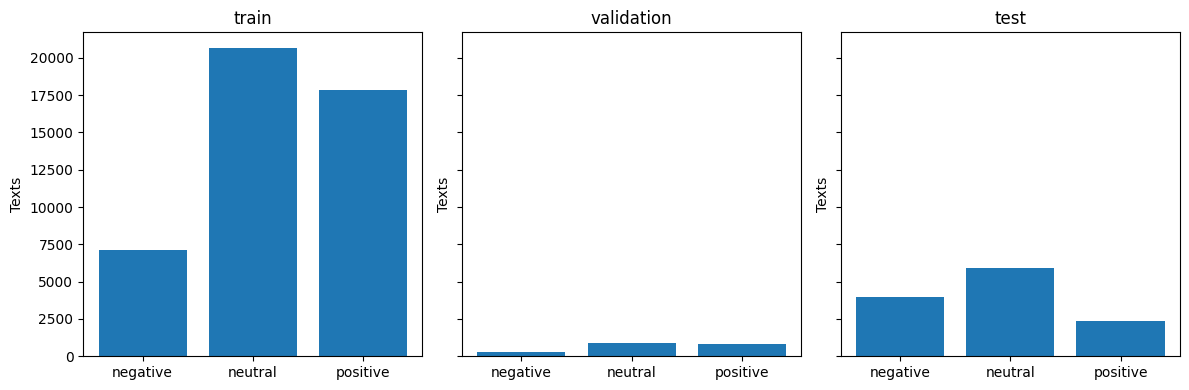

In [5]:
URL_RE = re.compile(r"https?://\S+|www\.\S+|\bhttp\b", re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+", re.IGNORECASE)
HASHTAG_RE = re.compile(r"#\w+")

def has_url(text):
    return bool(URL_RE.search(str(text)))

def has_mention(text):
    return bool(MENTION_RE.search(str(text)))

def has_hashtag(text):
    return bool(HASHTAG_RE.search(str(text)))

def has_emoji(text):
    return emoji.emoji_count(str(text)) > 0

def has_uppercase(text):
    return any(word.isupper() and len(word) > 2 for word in str(text).split())

summary_rows = []
split_data = [("train", df_train), ("validation", df_val), ("test", df_test)]

for name, df in split_data:
    counts = df["label"].value_counts()
    words = df["text"].str.split().apply(len)

    summary_rows.append({
        "split": name,
        "rows": len(df),
        "negative": int(counts.get(0, 0)),
        "neutral": int(counts.get(1, 0)),
        "positive": int(counts.get(2, 0)),
        "duplicates": int(df["text"].duplicated().sum()),
        "missing_texts": int(df["text"].isna().sum()),
        "mean_words": float(words.mean()),
        "p95_words": float(np.percentile(words, 95)),
        "urls": int(df["text"].apply(has_url).sum()),
        "mentions": int(df["text"].apply(has_mention).sum()),
        "hashtags": int(df["text"].apply(has_hashtag).sum()),
        "emojis": int(df["text"].apply(has_emoji).sum()),
        "uppercase_words": int(df["text"].apply(has_uppercase).sum())
    })

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)

train_texts = set(df_train_full["text"])
val_texts = set(df_val_full["text"])
test_texts = set(df_test_full["text"])

print(dataset_summary.round(2).to_string(index=False))
print("Train-validation overlap:", len(train_texts & val_texts))
print("Train-test overlap:", len(train_texts & test_texts))
print("Validation-test overlap:", len(val_texts & test_texts))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (name, df) in zip(axes, split_data):
    counts = df["label_name"].value_counts().reindex(["negative", "neutral", "positive"], fill_value=0)
    ax.bar(counts.index, counts.values)
    ax.set_title(name)
    ax.set_ylabel("Texts")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=180)
plt.show()

In [6]:
def clean_text(text):
    text = str(text)
    text = URL_RE.sub(" url ", text)
    text = MENTION_RE.sub(" user ", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"n't\b", " not", text)
    text = text.lower()
    text = re.sub(r"([!?])", r" \1 ", text)
    text = re.sub(r"[^a-z0-9_!?']+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def clean_bertweet(text):
    text = URL_RE.sub("HTTPURL", str(text))
    text = MENTION_RE.sub("@USER", text)
    return re.sub(r"\s+", " ", text).strip()

for df in [df_train, df_val, df_test]:
    df["text_clean"] = df["text"].apply(clean_text)
    df["text_bertweet"] = df["text"].apply(clean_bertweet)
    df["word_count"] = df["text_clean"].str.split().apply(len)

MAX_LEN = int(np.percentile(df_train["word_count"], 99))
MAX_LEN = max(16, min(MAX_LEN, 64))

y_train = df_train["label"].to_numpy()
y_val = df_val["label"].to_numpy()
y_test = df_test["label"].to_numpy()

weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_train)
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
SOFT_WEIGHTS = torch.sqrt(CLASS_WEIGHTS)

print("Sequence length:", MAX_LEN)
print("Class weights:", np.round(weights, 4))

Sequence length: 31
Class weights: [2.1437 0.7355 0.8519]


In [7]:
start = time.time()

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=90000,
    sublinear_tf=True,
    strip_accents="unicode",
    token_pattern=r"(?u)\b\w+\b",
    dtype=np.float32
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=90000,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_word = word_vectorizer.fit_transform(df_train["text_clean"])
X_val_word = word_vectorizer.transform(df_val["text_clean"])
X_test_word = word_vectorizer.transform(df_test["text_clean"])

X_train_char = char_vectorizer.fit_transform(df_train["text_clean"])
X_val_char = char_vectorizer.transform(df_val["text_clean"])
X_test_char = char_vectorizer.transform(df_test["text_clean"])

X_train = hstack([X_train_word, X_train_char]).tocsr()
X_val = hstack([X_val_word, X_val_char]).tocsr()
X_test = hstack([X_test_word, X_test_char]).tocsr()

best_svc = None
best_svc_f1 = -1
best_svc_settings = None
svc_rows = []

for class_weight in [None, "balanced"]:
    for c_value in [0.5, 1.0, 2.0]:
        model = LinearSVC(
            C=c_value,
            class_weight=class_weight,
            max_iter=10000,
            random_state=SEED
        )
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        score = f1_score(y_val, val_pred, average="macro")

        svc_rows.append({
            "C": c_value,
            "class_weight": "none" if class_weight is None else "balanced",
            "validation_macro_f1": score
        })

        print("SVC", c_value, class_weight, round(score, 4))

        if score > best_svc_f1:
            best_svc_f1 = score
            best_svc = model
            best_svc_settings = (c_value, class_weight)

svc_train_time = time.time() - start
svc_search = pd.DataFrame(svc_rows)
svc_search.to_csv(RESULTS_DIR / "svc_search.csv", index=False)

with open(MODELS_DIR / "word_vectorizer.pkl", "wb") as file:
    pickle.dump(word_vectorizer, file)

with open(MODELS_DIR / "char_vectorizer.pkl", "wb") as file:
    pickle.dump(char_vectorizer, file)

with open(MODELS_DIR / "linear_svc.pkl", "wb") as file:
    pickle.dump(best_svc, file)

print("Best SVC:", best_svc_settings)
print("Validation F1:", round(best_svc_f1, 4))

SVC 0.5 None 0.6605
SVC 1.0 None 0.6556
SVC 2.0 None 0.6549
SVC 0.5 balanced 0.6677
SVC 1.0 balanced 0.6571
SVC 2.0 balanced 0.6516
Best SVC: (0.5, 'balanced')
Validation F1: 0.6677


In [8]:
MIN_FREQ = 2
MAX_VOCAB = 50000

def build_vocab(texts):
    counter = Counter()

    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}

    for word, count in counter.most_common():
        if count < MIN_FREQ or len(vocab) >= MAX_VOCAB:
            break
        vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(df_train["text_clean"])
VOCAB_SIZE = len(vocab)

with open(MODELS_DIR / "vocabulary.pkl", "wb") as file:
    pickle.dump(vocab, file)

def encode(text):
    ids = [vocab.get(word, 1) for word in text.split()[:MAX_LEN]]
    return ids + [0] * (MAX_LEN - len(ids))

class WordDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = np.asarray(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        x = torch.tensor(encode(self.texts.iloc[index]), dtype=torch.long)
        y = torch.tensor(self.labels[index], dtype=torch.long)
        return x, y

train_word_ds = WordDataset(df_train["text_clean"], y_train)
val_word_ds = WordDataset(df_val["text_clean"], y_val)
test_word_ds = WordDataset(df_test["text_clean"], y_test)

def word_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(train_word_ds, batch_size=64, shuffle=True, generator=generator)

val_word_loader = DataLoader(val_word_ds, batch_size=128, shuffle=False)
test_word_loader = DataLoader(test_word_ds, batch_size=128, shuffle=False)

print("Vocabulary:", VOCAB_SIZE)
print("Train batches:", len(word_train_loader(SEED)))

Vocabulary: 20555
Train batches: 713


In [9]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(128, 100, 2),
            nn.Conv1d(128, 100, 3),
            nn.Conv1d(128, 100, 4)
        ])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(300, 3)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        values = []

        for conv in self.convs:
            value = F.relu(conv(x))
            value = F.adaptive_max_pool1d(value, 1).squeeze(2)
            values.append(value)

        x = torch.cat(values, dim=1)
        return self.fc(self.dropout(x))


class BiGRUAttention(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 200, padding_idx=0)
        self.embedding_dropout = nn.Dropout(0.2)
        self.gru = nn.GRU(200, 128, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(256, 1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, 3)

    def forward(self, x):
        mask = x != 0
        lengths = mask.sum(dim=1).clamp(min=1).cpu()
        x = self.embedding_dropout(self.embedding(x))
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed, _ = self.gru(packed)
        x, _ = pad_packed_sequence(packed, batch_first=True, total_length=mask.size(1))
        scores = self.attention(torch.tanh(x)).squeeze(2)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        x = torch.bmm(weights.unsqueeze(1), x).squeeze(1)
        return self.fc(self.dropout(x))

print("Word models ready")

Word models ready


In [10]:
def evaluate_word(model, loader, weights, smoothing):
    model.eval()
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=smoothing)
    losses = []
    probs = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            losses.append(criterion(logits, y).item() * len(y))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            labels.extend(y.cpu().numpy())

    probs = np.vstack(probs)
    labels = np.asarray(labels)
    preds = probs.argmax(axis=1)
    loss = sum(losses) / len(labels)
    score = f1_score(labels, preds, average="macro")
    return loss, score, probs


def predict_word(model, loader):
    model.eval()
    probs = []
    start = time.time()

    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())

    return np.vstack(probs), time.time() - start

def train_word(model, train_loader, val_loader, name, seed, lr, smoothing):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )
    criterion = nn.CrossEntropyLoss(weight=SOFT_WEIGHTS, label_smoothing=smoothing)

    best_score = -1
    waiting = 0
    history = []
    checkpoint = MODELS_DIR / (name + "_" + str(seed) + ".pt")

    for epoch in range(15):
        model.train()
        total_loss = 0
        total_items = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * len(y)
            total_items += len(y)

        train_loss = total_loss / total_items
        val_loss, val_f1, _ = evaluate_word(model, val_loader, SOFT_WEIGHTS, smoothing)
        history.append([epoch + 1, train_loss, val_loss, val_f1])
        scheduler.step(val_f1)

        print(name, seed, epoch + 1, round(train_loss, 4), round(val_f1, 4))

        if val_f1 > best_score + 0.0001:
            best_score = val_f1
            waiting = 0
            torch.save(model.state_dict(), checkpoint)
        else:
            waiting += 1

        if waiting >= 4:
            break

    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    return model, pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss", "val_f1"]), checkpoint

In [11]:
textcnn_runs = []
textcnn_val_probs = []
textcnn_test_probs = []
textcnn_history = None
textcnn_params = 0

for seed in SEEDS:
    set_seed(seed)
    model = TextCNN(VOCAB_SIZE).to(DEVICE)
    textcnn_params = sum(p.numel() for p in model.parameters())

    start = time.time()
    model, history, checkpoint = train_word(
        model,
        word_train_loader(seed),
        val_word_loader,
        "textcnn",
        seed,
        0.001,
        0.0
    )
    train_time = time.time() - start

    val_loss, val_f1, val_probs = evaluate_word(model, val_word_loader, SOFT_WEIGHTS, 0.0)

    test_probs, inference_time = predict_word(model, test_word_loader)

    textcnn_runs.append({
        "model": "TextCNN",
        "seed": seed,
        "validation_macro_f1": val_f1,
        "training_time_seconds": train_time,
        "inference_time_seconds": inference_time,
        "checkpoint": str(checkpoint)
    })

    textcnn_val_probs.append(val_probs)
    textcnn_test_probs.append(test_probs)

    if seed == 42:
        textcnn_history = history

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

textcnn_val_ensemble = np.mean(np.stack(textcnn_val_probs), axis=0)
textcnn_test_ensemble = np.mean(np.stack(textcnn_test_probs), axis=0)
textcnn_val_pred = textcnn_val_ensemble.argmax(axis=1)
textcnn_test_pred = textcnn_test_ensemble.argmax(axis=1)

print("TextCNN validation F1:", round(f1_score(y_val, textcnn_val_pred, average="macro"), 4))

textcnn 13 1 1.01 0.4923
textcnn 13 2 0.8818 0.5847
textcnn 13 3 0.795 0.6194
textcnn 13 4 0.7188 0.6314
textcnn 13 5 0.6474 0.6304
textcnn 13 6 0.5808 0.6339
textcnn 13 7 0.525 0.6229
textcnn 13 8 0.4672 0.6176
textcnn 13 9 0.3783 0.6138
textcnn 13 10 0.3309 0.6102
textcnn 42 1 1.0076 0.5157
textcnn 42 2 0.8793 0.5835
textcnn 42 3 0.7911 0.6158
textcnn 42 4 0.7167 0.6239
textcnn 42 5 0.6432 0.6248
textcnn 42 6 0.5808 0.6296
textcnn 42 7 0.5201 0.6227
textcnn 42 8 0.4646 0.6196
textcnn 42 9 0.3782 0.618
textcnn 42 10 0.3307 0.6187
textcnn 77 1 1.0063 0.5211
textcnn 77 2 0.8805 0.5768
textcnn 77 3 0.7954 0.5992
textcnn 77 4 0.7208 0.6188
textcnn 77 5 0.6504 0.6298
textcnn 77 6 0.5845 0.6218
textcnn 77 7 0.5224 0.6274
textcnn 77 8 0.4288 0.6219
textcnn 77 9 0.3838 0.6227
TextCNN validation F1: 0.6571


In [12]:
bigru_runs = []
bigru_val_probs = []
bigru_test_probs = []
bigru_history = None
bigru_params = 0

for seed in SEEDS:
    set_seed(seed)
    model = BiGRUAttention(VOCAB_SIZE).to(DEVICE)
    bigru_params = sum(p.numel() for p in model.parameters())

    start = time.time()
    model, history, checkpoint = train_word(
        model,
        word_train_loader(seed),
        val_word_loader,
        "bigru",
        seed,
        0.0005,
        0.05
    )
    train_time = time.time() - start

    val_loss, val_f1, val_probs = evaluate_word(model, val_word_loader, SOFT_WEIGHTS, 0.05)

    test_probs, inference_time = predict_word(model, test_word_loader)

    bigru_runs.append({
        "model": "BiGRU",
        "seed": seed,
        "validation_macro_f1": val_f1,
        "training_time_seconds": train_time,
        "inference_time_seconds": inference_time,
        "checkpoint": str(checkpoint)
    })

    bigru_val_probs.append(val_probs)
    bigru_test_probs.append(test_probs)

    if seed == 42:
        bigru_history = history

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

bigru_val_ensemble = np.mean(np.stack(bigru_val_probs), axis=0)
bigru_test_ensemble = np.mean(np.stack(bigru_test_probs), axis=0)
bigru_val_pred = bigru_val_ensemble.argmax(axis=1)
bigru_test_pred = bigru_test_ensemble.argmax(axis=1)

print("BiGRU validation F1:", round(f1_score(y_val, bigru_val_pred, average="macro"), 4))

bigru 13 1 0.9716 0.5676
bigru 13 2 0.867 0.5827
bigru 13 3 0.8064 0.6187
bigru 13 4 0.7589 0.64
bigru 13 5 0.7106 0.631
bigru 13 6 0.6714 0.6285
bigru 13 7 0.614 0.6284
bigru 13 8 0.5924 0.6347
bigru 42 1 0.9739 0.556
bigru 42 2 0.8704 0.5986
bigru 42 3 0.8087 0.6275
bigru 42 4 0.7591 0.6375
bigru 42 5 0.7134 0.6427
bigru 42 6 0.6722 0.6418
bigru 42 7 0.6355 0.6474
bigru 42 8 0.5969 0.641
bigru 42 9 0.5663 0.6421
bigru 42 10 0.518 0.6426
bigru 42 11 0.5005 0.65
bigru 42 12 0.4826 0.638
bigru 42 13 0.4691 0.6374
bigru 42 14 0.4476 0.6413
bigru 42 15 0.4387 0.6414
bigru 77 1 0.9712 0.5523
bigru 77 2 0.8683 0.6002
bigru 77 3 0.8081 0.6223
bigru 77 4 0.7581 0.6365
bigru 77 5 0.7147 0.6448
bigru 77 6 0.6733 0.6486
bigru 77 7 0.6333 0.6481
bigru 77 8 0.5991 0.6284
bigru 77 9 0.5481 0.6403
bigru 77 10 0.5258 0.6357
BiGRU validation F1: 0.6723


In [13]:
BERTWEET_NAME = "vinai/bertweet-base"
bertweet_tokenizer = AutoTokenizer.from_pretrained(BERTWEET_NAME)
bertweet_tokenizer.save_pretrained(MODELS_DIR / "bertweet_tokenizer")

sample_texts = df_train["text_bertweet"].sample(
    min(10000, len(df_train)),
    random_state=SEED
)

lengths = []

for text in sample_texts:
    ids = bertweet_tokenizer(text, add_special_tokens=True, truncation=False)["input_ids"]
    lengths.append(len(ids))

BERTWEET_MAX_LEN = int(np.percentile(lengths, 99))
BERTWEET_MAX_LEN = max(64, min(BERTWEET_MAX_LEN, 128))

class BERTweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = np.asarray(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        values = bertweet_tokenizer(
            self.texts.iloc[index],
            padding="max_length",
            truncation=True,
            max_length=BERTWEET_MAX_LEN,
            return_tensors="pt"
        )

        return {
            "input_ids": values["input_ids"].squeeze(0),
            "attention_mask": values["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[index], dtype=torch.long)
        }

train_bertweet_ds = BERTweetDataset(df_train["text_bertweet"], y_train)
val_bertweet_ds = BERTweetDataset(df_val["text_bertweet"], y_val)
test_bertweet_ds = BERTweetDataset(df_test["text_bertweet"], y_test)

def bertweet_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(train_bertweet_ds, batch_size=16, shuffle=True, generator=generator)

val_bertweet_loader = DataLoader(val_bertweet_ds, batch_size=32, shuffle=False)
test_bertweet_loader = DataLoader(test_bertweet_ds, batch_size=32, shuffle=False)

print("BERTweet max length:", BERTWEET_MAX_LEN)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

BERTweet max length: 64


In [14]:
def evaluate_bertweet(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    losses = []
    probs = []
    labels = []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            y = batch["labels"].to(DEVICE)

            output = model(input_ids=ids, attention_mask=mask)
            losses.append(criterion(output.logits, y).item() * len(y))
            probs.append(torch.softmax(output.logits, dim=1).cpu().numpy())
            labels.extend(y.cpu().numpy())

    probs = np.vstack(probs)
    labels = np.asarray(labels)
    preds = probs.argmax(axis=1)
    return sum(losses) / len(labels), f1_score(labels, preds, average="macro"), probs


def predict_bertweet(model, loader):
    model.eval()
    probs = []
    start = time.time()

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            output = model(input_ids=ids, attention_mask=mask)
            probs.append(torch.softmax(output.logits, dim=1).cpu().numpy())

    return np.vstack(probs), time.time() - start

def train_bertweet(model, train_loader, val_loader, seed):
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.00002, weight_decay=0.01)
    total_steps = math.ceil(len(train_loader) / 2) * 4
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_score = -1
    waiting = 0
    history = []
    checkpoint = MODELS_DIR / ("bertweet_" + str(seed) + ".pt")

    for epoch in range(4):
        model.train()
        optimizer.zero_grad()
        total_loss = 0
        total_items = 0

        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            y = batch["labels"].to(DEVICE)

            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
                output = model(input_ids=ids, attention_mask=mask)
                raw_loss = criterion(output.logits, y)
                loss = raw_loss / 2

            scaler.scale(loss).backward()

            if (step + 1) % 2 == 0 or step + 1 == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += raw_loss.item() * len(y)
            total_items += len(y)

        train_loss = total_loss / total_items
        val_loss, val_f1, val_probs = evaluate_bertweet(model, val_loader)
        history.append([epoch + 1, train_loss, val_loss, val_f1])

        print("bertweet", seed, epoch + 1, round(train_loss, 4), round(val_f1, 4))

        if val_f1 > best_score + 0.0001:
            best_score = val_f1
            waiting = 0
            torch.save(model.state_dict(), checkpoint)
        else:
            waiting += 1

        if waiting >= 2:
            break

    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    return model, pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss", "val_f1"]), checkpoint


bertweet_runs = []
bertweet_val_probs = []
bertweet_test_probs = []
bertweet_history = None
bertweet_params = 0

for seed in SEEDS:
    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERTWEET_NAME,
        num_labels=3,
        id2label=LABEL_NAMES,
        label2id={value: key for key, value in LABEL_NAMES.items()}
    ).to(DEVICE)

    bertweet_params = sum(p.numel() for p in model.parameters())

    start = time.time()
    model, history, checkpoint = train_bertweet(
        model,
        bertweet_train_loader(seed),
        val_bertweet_loader,
        seed
    )
    train_time = time.time() - start

    val_loss, val_f1, val_probs = evaluate_bertweet(model, val_bertweet_loader)

    test_probs, inference_time = predict_bertweet(model, test_bertweet_loader)

    bertweet_runs.append({
        "model": "BERTweet",
        "seed": seed,
        "validation_macro_f1": val_f1,
        "training_time_seconds": train_time,
        "inference_time_seconds": inference_time,
        "checkpoint": str(checkpoint)
    })

    bertweet_val_probs.append(val_probs)
    bertweet_test_probs.append(test_probs)

    if seed == 42:
        bertweet_history = history

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

bertweet_val_ensemble = np.mean(np.stack(bertweet_val_probs), axis=0)
bertweet_test_ensemble = np.mean(np.stack(bertweet_test_probs), axis=0)
bertweet_val_pred = bertweet_val_ensemble.argmax(axis=1)
bertweet_test_pred = bertweet_test_ensemble.argmax(axis=1)

print("BERTweet validation F1:", round(f1_score(y_val, bertweet_val_pred, average="macro"), 4))

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


bertweet 42 1 0.7436 0.7159
bertweet 42 2 0.5789 0.7324
bertweet 42 3 0.4808 0.7343
bertweet 42 4 0.4061 0.7407


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


bertweet 77 1 0.7442 0.7387
bertweet 77 2 0.5783 0.7346
bertweet 77 3 0.4789 0.7399
bertweet 77 4 0.4039 0.7427
BERTweet validation F1: 0.7449


In [15]:
def get_size(path):
    return Path(path).stat().st_size / (1024 ** 2)

def model_metrics(name, y_true, pred, val_f1, train_time, inference_time, params, size):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        pred,
        labels=[0, 1, 2],
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = precision_recall_fscore_support(
        y_true,
        pred,
        average="weighted",
        zero_division=0
    )[2]

    row = {
        "model": name,
        "validation_macro_f1": val_f1,
        "test_accuracy": accuracy_score(y_true, pred),
        "test_macro_precision": macro_precision,
        "test_macro_recall": macro_recall,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "training_time_seconds": train_time,
        "inference_time_seconds": inference_time,
        "parameters": params,
        "model_size_mb": size
    }

    class_rows = []

    for index, label in enumerate(["negative", "neutral", "positive"]):
        class_rows.append({
            "model": name,
            "class": label,
            "precision": precision[index],
            "recall": recall[index],
            "f1": f1[index],
            "support": int(support[index])
        })

    return row, class_rows


start = time.time()
svc_test_pred = best_svc.predict(X_test)
svc_inference_time = time.time() - start

svc_size = (
    get_size(MODELS_DIR / "word_vectorizer.pkl")
    + get_size(MODELS_DIR / "char_vectorizer.pkl")
    + get_size(MODELS_DIR / "linear_svc.pkl")
)

textcnn_size = sum(get_size(MODELS_DIR / ("textcnn_" + str(seed) + ".pt")) for seed in SEEDS)
bigru_size = sum(get_size(MODELS_DIR / ("bigru_" + str(seed) + ".pt")) for seed in SEEDS)
bertweet_size = sum(get_size(MODELS_DIR / ("bertweet_" + str(seed) + ".pt")) for seed in SEEDS)

systems = [
    {
        "name": "TF-IDF + LinearSVC",
        "pred": svc_test_pred,
        "val_f1": best_svc_f1,
        "train_time": svc_train_time,
        "inference_time": svc_inference_time,
        "params": best_svc.coef_.size + best_svc.intercept_.size,
        "size": svc_size
    },
    {
        "name": "TextCNN ensemble",
        "pred": textcnn_test_pred,
        "val_f1": f1_score(y_val, textcnn_val_pred, average="macro"),
        "train_time": sum(row["training_time_seconds"] for row in textcnn_runs),
        "inference_time": sum(row["inference_time_seconds"] for row in textcnn_runs),
        "params": textcnn_params * len(SEEDS),
        "size": textcnn_size
    },
    {
        "name": "BiGRU ensemble",
        "pred": bigru_test_pred,
        "val_f1": f1_score(y_val, bigru_val_pred, average="macro"),
        "train_time": sum(row["training_time_seconds"] for row in bigru_runs),
        "inference_time": sum(row["inference_time_seconds"] for row in bigru_runs),
        "params": bigru_params * len(SEEDS),
        "size": bigru_size
    },
    {
        "name": "BERTweet ensemble",
        "pred": bertweet_test_pred,
        "val_f1": f1_score(y_val, bertweet_val_pred, average="macro"),
        "train_time": sum(row["training_time_seconds"] for row in bertweet_runs),
        "inference_time": sum(row["inference_time_seconds"] for row in bertweet_runs),
        "params": bertweet_params * len(SEEDS),
        "size": bertweet_size
    }
]

final_rows = []
class_rows = []

for system in systems:
    row, current_class_rows = model_metrics(
        system["name"],
        y_test,
        system["pred"],
        system["val_f1"],
        system["train_time"],
        system["inference_time"],
        system["params"],
        system["size"]
    )
    final_rows.append(row)
    class_rows.extend(current_class_rows)

final_results = pd.DataFrame(final_rows)
class_results = pd.DataFrame(class_rows)

seed_rows = []

for runs, probs_list in [
    (textcnn_runs, textcnn_test_probs),
    (bigru_runs, bigru_test_probs),
    (bertweet_runs, bertweet_test_probs)
]:
    for run, probs in zip(runs, probs_list):
        pred = probs.argmax(axis=1)
        seed_rows.append({
            "model": run["model"],
            "seed": run["seed"],
            "validation_macro_f1": run["validation_macro_f1"],
            "test_accuracy": accuracy_score(y_test, pred),
            "test_macro_f1": f1_score(y_test, pred, average="macro"),
            "training_time_seconds": run["training_time_seconds"],
            "inference_time_seconds": run["inference_time_seconds"]
        })

seed_results = pd.DataFrame(seed_rows)

predictions = df_test[["text", "label", "label_name"]].copy().reset_index(drop=True)
predictions["svc_prediction"] = svc_test_pred
predictions["textcnn_prediction"] = textcnn_test_pred
predictions["bigru_prediction"] = bigru_test_pred
predictions["bertweet_prediction"] = bertweet_test_pred

final_results.to_csv(RESULTS_DIR / "final_results.csv", index=False)
seed_results.to_csv(RESULTS_DIR / "seed_results.csv", index=False)
class_results.to_csv(RESULTS_DIR / "class_results.csv", index=False)
predictions.to_csv(RESULTS_DIR / "predictions.csv", index=False)

print(final_results.round(4).to_string(index=False))
print()
print(seed_results.round(4).to_string(index=False))

             model  validation_macro_f1  test_accuracy  test_macro_precision  test_macro_recall  test_macro_f1  test_weighted_f1  training_time_seconds  inference_time_seconds  parameters  model_size_mb
TF-IDF + LinearSVC               0.6677         0.6121                0.6019             0.6172         0.6079            0.6124                71.5808                  0.0164      540003         9.7442
  TextCNN ensemble               0.6571         0.5991                0.5879             0.5962         0.5894            0.5986               129.8154                  1.4016     8242329        31.4533
    BiGRU ensemble               0.6723         0.6083                0.5983             0.6021         0.5996            0.6079               326.8167                  1.6901    13096404        49.9696
 BERTweet ensemble               0.7449         0.7178                0.7098             0.7304         0.7184            0.7173              3202.0207                141.2738   404706825 

In [16]:
def bootstrap_f1(y_true, pred, samples=500, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    size = len(y_true)

    for _ in range(samples):
        indexes = rng.integers(0, size, size)
        score = f1_score(
            y_true[indexes],
            pred[indexes],
            labels=[0, 1, 2],
            average="macro",
            zero_division=0
        )
        scores.append(score)

    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)


stat_rows = []

for system in systems:
    low, high = bootstrap_f1(y_test, system["pred"])

    stat_rows.append({
        "test": "bootstrap_macro_f1",
        "model_a": system["name"],
        "model_b": "",
        "value_1": low,
        "value_2": high,
        "p_value": np.nan,
        "p_value_adjusted": np.nan
    })

pairs = []

for i in range(len(systems)):
    for j in range(i + 1, len(systems)):
        a = systems[i]
        b = systems[j]
        a_correct = a["pred"] == y_test
        b_correct = b["pred"] == y_test
        a_only = int(np.sum(a_correct & ~b_correct))
        b_only = int(np.sum(~a_correct & b_correct))
        total = a_only + b_only
        p_value = 1.0 if total == 0 else binomtest(min(a_only, b_only), total, 0.5).pvalue

        pairs.append({
            "test": "mcnemar_accuracy",
            "model_a": a["name"],
            "model_b": b["name"],
            "value_1": a_only,
            "value_2": b_only,
            "p_value": p_value
        })

tests_count = len(pairs)

for row in pairs:
    row["p_value_adjusted"] = min(row["p_value"] * tests_count, 1.0)
    stat_rows.append(row)

statistics = pd.DataFrame(stat_rows)
statistics.to_csv(RESULTS_DIR / "statistical_tests.csv", index=False)

print(statistics.round(6).to_string(index=False))

              test            model_a           model_b     value_1     value_2  p_value  p_value_adjusted
bootstrap_macro_f1 TF-IDF + LinearSVC                      0.599570    0.616019      NaN               NaN
bootstrap_macro_f1   TextCNN ensemble                      0.580530    0.598057      NaN               NaN
bootstrap_macro_f1     BiGRU ensemble                      0.590879    0.609060      NaN               NaN
bootstrap_macro_f1  BERTweet ensemble                      0.710296    0.726340      NaN               NaN
  mcnemar_accuracy TF-IDF + LinearSVC  TextCNN ensemble 1513.000000 1353.000000 0.002971          0.017828
  mcnemar_accuracy TF-IDF + LinearSVC    BiGRU ensemble 1376.000000 1329.000000 0.376456          1.000000
  mcnemar_accuracy TF-IDF + LinearSVC BERTweet ensemble 1337.000000 2635.000000 0.000000          0.000000
  mcnemar_accuracy   TextCNN ensemble    BiGRU ensemble 1088.000000 1201.000000 0.019214          0.115285
  mcnemar_accuracy   TextCNN ensemble

In [17]:
error_data = predictions.copy()

prediction_columns = {
    "TF-IDF + LinearSVC": "svc_prediction",
    "TextCNN ensemble": "textcnn_prediction",
    "BiGRU ensemble": "bigru_prediction",
    "BERTweet ensemble": "bertweet_prediction"
}

for name, column in prediction_columns.items():
    simple_name = column.replace("_prediction", "")
    error_data[simple_name + "_correct"] = error_data[column] == error_data["label"]

error_data["word_count"] = error_data["text"].str.split().apply(len)
error_data["has_negation"] = error_data["text"].str.contains(
    r"\b(not|no|never|cannot|nothing|nobody)\b|n't\b",
    case=False,
    regex=True
)
error_data["has_url"] = error_data["text"].apply(has_url)
error_data["has_mention"] = error_data["text"].apply(has_mention)
error_data["has_hashtag"] = error_data["text"].apply(has_hashtag)
error_data["has_emoji"] = error_data["text"].apply(has_emoji)

correct_columns = [
    "svc_correct",
    "textcnn_correct",
    "bigru_correct",
    "bertweet_correct"
]

error_data["correct_models"] = error_data[correct_columns].sum(axis=1)
error_data["all_correct"] = error_data["correct_models"] == 4
error_data["all_wrong"] = error_data["correct_models"] == 0
error_data["only_bertweet_correct"] = (
    error_data["bertweet_correct"] & (error_data["correct_models"] == 1)
)

group_rows = []
groups = {
    "negation": error_data["has_negation"],
    "url": error_data["has_url"],
    "mention": error_data["has_mention"],
    "hashtag": error_data["has_hashtag"],
    "emoji": error_data["has_emoji"],
    "1-6 words": error_data["word_count"] <= 6,
    "7-15 words": error_data["word_count"].between(7, 15),
    "16-25 words": error_data["word_count"].between(16, 25),
    "26+ words": error_data["word_count"] >= 26
}

for group_name, mask in groups.items():
    current = error_data[mask]

    for model_name, prediction_column in prediction_columns.items():
        group_rows.append({
            "group": group_name,
            "model": model_name,
            "texts": len(current),
            "accuracy": accuracy_score(current["label"], current[prediction_column]) if len(current) else np.nan
        })

group_results = pd.DataFrame(group_rows)

error_data.to_csv(RESULTS_DIR / "error_analysis.csv", index=False)
group_results.to_csv(RESULTS_DIR / "group_results.csv", index=False)

print("All correct:", int(error_data["all_correct"].sum()))
print("All wrong:", int(error_data["all_wrong"].sum()))
print("Only BERTweet correct:", int(error_data["only_bertweet_correct"].sum()))

/tmp/ipykernel_510/278544891.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  error_data["has_negation"] = error_data["text"].str.contains(


All correct: 4667
All wrong: 1505
Only BERTweet correct: 1420


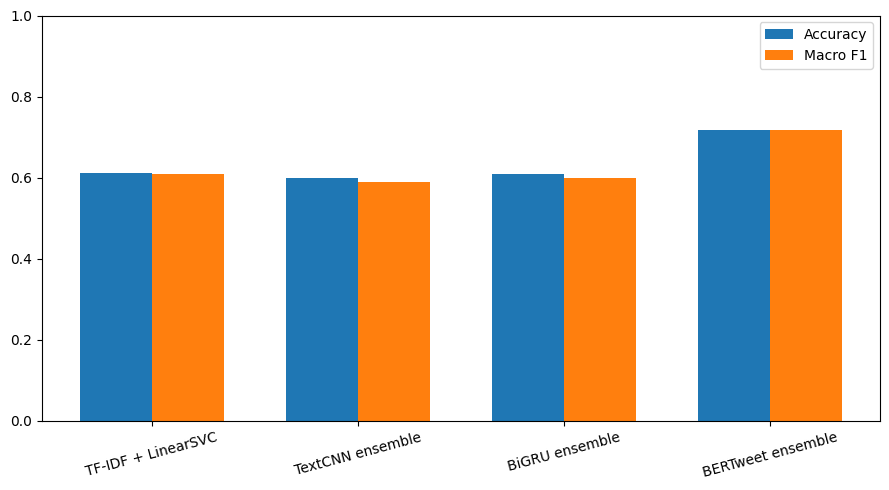

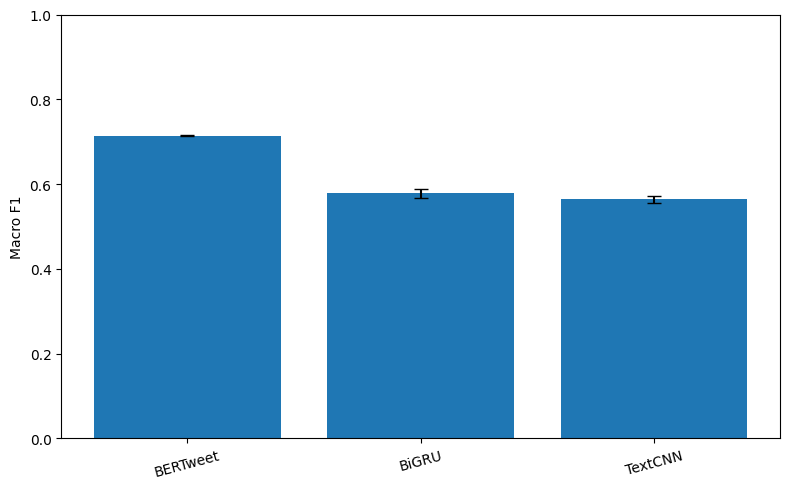

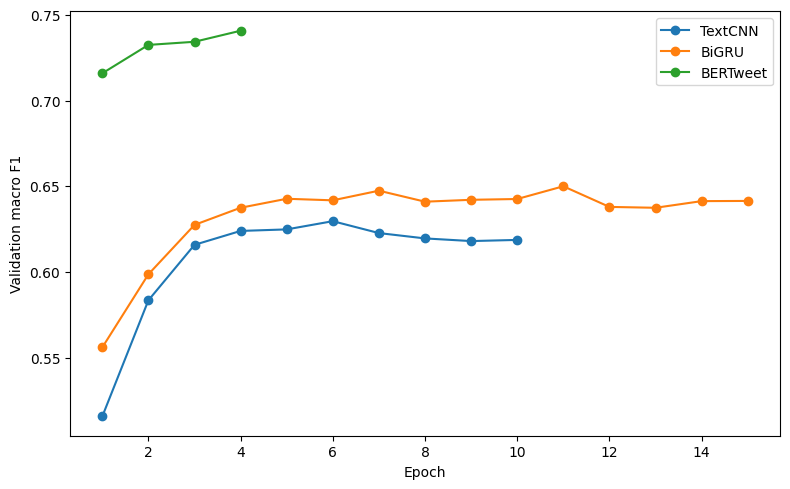

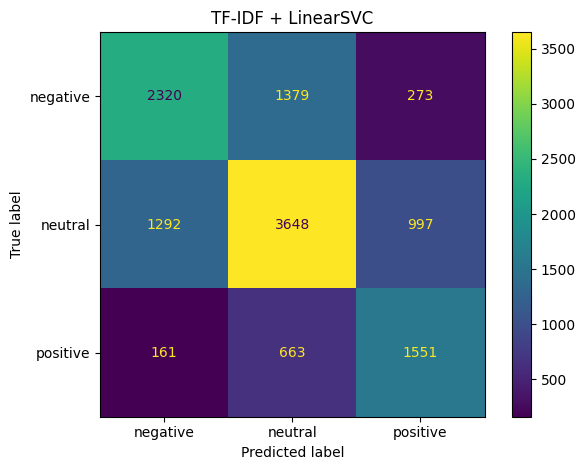

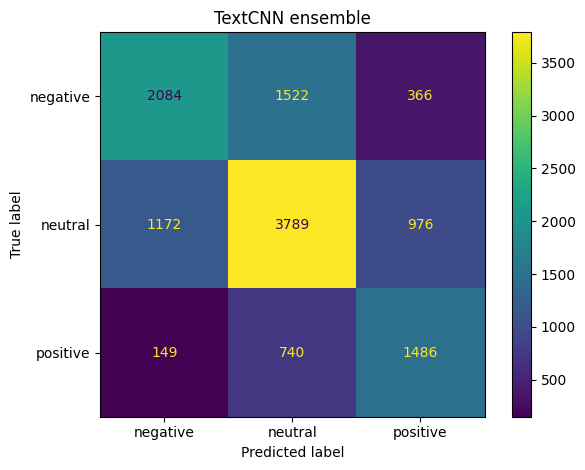

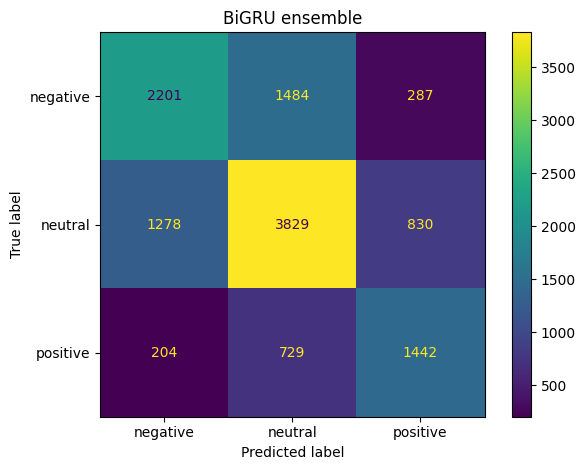

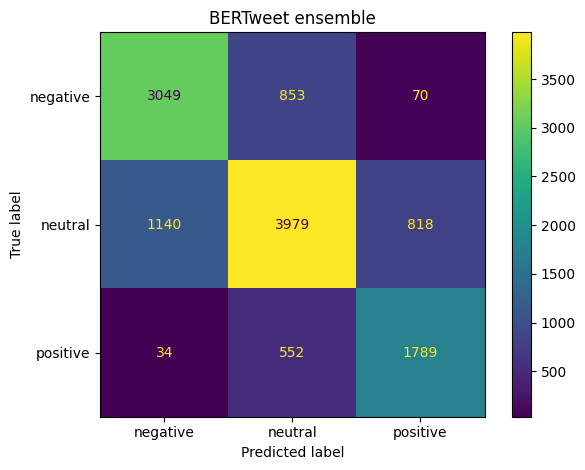

Figures saved


In [18]:
plt.figure(figsize=(9, 5))
x = np.arange(len(final_results))
width = 0.35

plt.bar(x - width / 2, final_results["test_accuracy"], width, label="Accuracy")
plt.bar(x + width / 2, final_results["test_macro_f1"], width, label="Macro F1")
plt.xticks(x, final_results["model"], rotation=15)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_scores.png", dpi=180)
plt.show()

seed_summary = seed_results.groupby("model")["test_macro_f1"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(seed_summary["model"], seed_summary["mean"], yerr=seed_summary["std"], capsize=5)
plt.ylim(0, 1)
plt.ylabel("Macro F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "seed_stability.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(textcnn_history["epoch"], textcnn_history["val_f1"], marker="o", label="TextCNN")
plt.plot(bigru_history["epoch"], bigru_history["val_f1"], marker="o", label="BiGRU")
plt.plot(bertweet_history["epoch"], bertweet_history["val_f1"], marker="o", label="BERTweet")
plt.xlabel("Epoch")
plt.ylabel("Validation macro F1")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_history.png", dpi=180)
plt.show()

for system in systems:
    matrix = confusion_matrix(y_test, system["pred"], labels=[0, 1, 2])
    name = system["name"].lower().replace(" + ", "_").replace(" ", "_")
    display = ConfusionMatrixDisplay(matrix, display_labels=["negative", "neutral", "positive"])
    display.plot(values_format="d")
    plt.title(system["name"])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / ("confusion_" + name + ".png"), dpi=180)
    plt.show()

print("Figures saved")

In [19]:
required = [
    RESULTS_DIR / "dataset_summary.csv",
    RESULTS_DIR / "svc_search.csv",
    RESULTS_DIR / "final_results.csv",
    RESULTS_DIR / "seed_results.csv",
    RESULTS_DIR / "class_results.csv",
    RESULTS_DIR / "predictions.csv",
    RESULTS_DIR / "statistical_tests.csv",
    RESULTS_DIR / "error_analysis.csv",
    RESULTS_DIR / "group_results.csv"
]

missing = [str(path) for path in required if not path.exists()]

if missing:
    raise FileNotFoundError(missing)

zip_path = Path("/content/sentiment_project_results.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as file:
    for folder in [RESULTS_DIR, FIGURES_DIR]:
        for path in folder.rglob("*"):
            if path.is_file():
                file.write(path, path.relative_to(BASE_DIR))

print("Checks passed")
print("Results:", zip_path)
print("Models:", MODELS_DIR)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    pass

Checks passed
Results: /content/sentiment_project_results.zip
Models: /content/sentiment_project/models


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>